In [1]:
using DifferentialEquations
using ReactionMechanismSimulator
using PyPlot

In [2]:
outdict = readinput("chem293.rms")

[21:33:19] WARNING: not removing hydrogen atom without neighbors
[21:33:19] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator /home/ssun30/RMG-electrocat/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator /home/ssun30/RMG-electrocat/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator /home/ssun30/RMG-electrocat/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator /home/ssun30/RMG-electrocat/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator /home/ssun30/RMG-electrocat/ReactionMechanismSimulator.j

Dict{Any, Any} with 4 entries:
  "Solvents"              => Solvent[Solvent("water", RiedelViscosity{Float64}(…
  Set(["surface", "gas"]) => Dict{Any, Any}("Reactions"=>ElementaryReaction[vac…
  "gas"                   => Dict{Any, Any}("Species"=>Species[Species{NASA{Emp…
  "surface"               => Dict{Any, Any}("Species"=>Species[Species{NASA{Emp…

In [3]:
liqspcs = outdict["gas"]["Species"]
liqrxns = outdict["gas"]["Reactions"]
surfspcs = outdict["surface"]["Species"]
surfrxns = outdict["surface"]["Reactions"]
interfacerxns = outdict[Set(["surface", "gas"])]["Reactions"]
solv = outdict["Solvents"][1];

In [4]:
fieldnames(typeof(interfacerxns[15]))

(:index, :reactants, :reactantinds, :products, :productinds, :kinetics, :electronchange, :radicalchange, :reversible, :forwardable, :pairs, :fragmentbasedreactants, :fragmentbasedproducts, :fragmentbasedreactantinds, :fragmentbasedproductinds, :comment)

In [5]:
interfacerxns

591-element Vector{ElementaryReaction}:
 vacantX+CO2<=>CO2X
 proton+CO2X<=>CHO2X
 proton+CO2X<=>CO2HX
 proton+CHO2X<=>CH2O2X
 proton+CO2HX<=>CH2O2X
 proton+OCX<=>CHOX
 proton+CHOX<=>CH2OX
 vacantX+vacantX+CO2<=>OX+OCX
 OX+proton<=>HOX
 vacantX+C=O<=>CH2OX
 ⋮
 vacantX+vacantX+COC=CO<=>CH3X+OC=CO[Pt]
 vacantX+vacantX+CCOC=CO<=>OC=CO[Pt]+CC[Pt]
 HX+O=C=CO<=>OC=C(O)[Pt]
 vacantX+vacantX+OC=CO<=>HX+OC=C(O)[Pt]
 proton+O=C=CO.[Pt]<=>OC=C(O)[Pt]
 proton+OC=C(O)[Pt]<=>OC=CO.[Pt]
 vacantX+vacantX+CC(O)=CO<=>CH3X+OC=C(O)[Pt]
 proton+OC=C(O)[Pt]<=>OCC(O)=[Pt]
 proton+OC=C(O)[Pt]<=>H2O+OC=C=[Pt]

In [6]:
sitedensity = 2.292e-5 # Ag111
liq = IdealDiluteSolution(liqspcs,liqrxns,solv,name="liquid",diffusionlimited=true);
surf = IdealSurface(surfspcs,surfrxns,sitedensity,name="surface");

In [7]:
initialcondsliq = Dict(["proton"=>10.0^-4,
        "CO2"=>10.0^-3*10^6,
        "V"=>1.0,"T"=>300,"Phi"=>0.0,"d"=>0.0]);
AVratio = 36
initialcondssurf = Dict(["CO2X"=>0.4*sitedensity*AVratio,
        "CHO2X"=>0.1*sitedensity*AVratio,
        "CO2HX"=>0.1*sitedensity*AVratio,
        "OX"=>0.1*sitedensity*AVratio,
        "OCX"=>0.1*sitedensity*AVratio,
        "vacantX"=>0.1*sitedensity*AVratio,
        "CH2O2X"=>0.05*sitedensity*AVratio,
        "CHOX"=>0.04*sitedensity*AVratio,
        "CH2OX"=>0.01*sitedensity*AVratio,
        "A"=>1.0*AVratio,"T"=>300,"Phi"=>-1.414]);

In [8]:
domainliq,y0liq,pliq = ConstantTVDomain(phase=liq,
    initialconds=initialcondsliq,constantspecies=["proton","CO2"]);
domaincat,y0cat,pcat = ConstantTAPhiDomain(phase=surf,
    initialconds=initialcondssurf);

In [9]:
domaincat

ConstantTAPhiDomain{IdealSurface{Tuple{Arrheniusvec{Vector{Float64}, Vector{Float64}, Vector{Float64}}}, SparseArrays.SparseMatrixCSC{Float64, Int64}, Vector{Float64}, ReactionMechanismSimulator.NASAvec{EmptyThermoUncertainty}, Vector{Float64}}, Int64, Float64, Float64, Integer, Vector{Int64}}(IdealSurface{Tuple{Arrheniusvec{Vector{Float64}, Vector{Float64}, Vector{Float64}}}, SparseArrays.SparseMatrixCSC{Float64, Int64}, Vector{Float64}, ReactionMechanismSimulator.NASAvec{EmptyThermoUncertainty}, Vector{Float64}}
  name: String "surface"
  species: Array{Species}((135,))
  reactions: Array{ElementaryReaction}((5478,))
  stoichmatrix: SparseArrays.SparseMatrixCSC{Float64, Int64}
  Nrp: Array{Float64}((5478,)) [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  rxnarray: Array{Int64}((8, 5478)) [6 3 … 135 135; 5 0 … 134 134; … ; 0 0 … 0 0; 0 0 … 0 0]
  veckinetics: Tuple{Arrheniusvec{Vector{Float64}, Vector{Float64}, Vector{Float64}}

In [10]:
domainliq

ConstantTVDomain{IdealDiluteSolution{Tuple{}, SparseArrays.SparseMatrixCSC{Float64, Int64}, Vector{Float64}}, Int64, Float64, Float64, Integer, Vector{Int64}}(IdealDiluteSolution{Tuple{}, SparseArrays.SparseMatrixCSC{Float64, Int64}, Vector{Float64}}
  name: String "liquid"
  species: Array{Species}((158,))
  reactions: Array{ElementaryReaction}((0,))
  solvent: Solvent
  stoichmatrix: SparseArrays.SparseMatrixCSC{Float64, Int64}
  Nrp: Array{Float64}((0,)) Float64[]
  rxnarray: Array{Int64}((8, 0)) Matrix{Int64}(undef, 8, 0)
  veckinetics: Tuple{} ()
  veckineticsinds: Array{Int64}((0,)) Int64[]
  vecthermo: ReactionMechanismSimulator.NASAvec{EmptyThermoUncertainty}
  otherreactions: Array{ElementaryReaction}((0,))
  electronchange: Array{Float64}((0,)) Float64[]
  spcdict: Dict{String, Int64}
  reversibility: Array{Bool}((0,)) Bool[]
  forwardability: Array{Bool}((0,)) Bool[]
  diffusionlimited: Bool true
, [1, 158], [1, 158], [6, 5], 300.0, 1.0, 0.0, 0.0, Float64[], Float64[], Float

In [11]:
inter,pinter = ReactiveInternalInterfaceConstantTPhi(domainliq,
  domaincat,interfacerxns,298.15,AVratio*1.0);

In [12]:
@time react,y0,p = Reactor((domainliq,domaincat), (y0liq,y0cat), (0.0, 1.0e3), [inter], (pliq,pcat,pinter));


 11.433909 seconds (50.52 M allocations: 3.095 GiB, 9.19% gc time, 99.48% compilation time: <1% of which was recompilation)


In [13]:
@time sol = solve(react.ode,DifferentialEquations.CVODE_BDF(),abstol=1e-16,reltol=1e-6);

  4.496705 seconds (18.78 M allocations: 2.104 GiB, 7.58% gc time, 88.29% compilation time)


In [14]:
sol

retcode: Success
Interpolation: 3rd order Hermite
t: 1237-element Vector{Float64}:
    0.0
    1.1666313651520811e-24
    2.3332627303041623e-24
    5.73110936593029e-24
    9.128956001556417e-24
    1.2526802637182544e-23
    1.592464927280867e-23
    1.9322495908434798e-23
    2.2720342544060925e-23
    2.611818917968705e-23
    ⋮
  805.0777373520897
  830.3267984300564
  855.5758595080232
  880.82492058599
  906.0739816639567
  931.3230427419235
  956.5721038198902
  981.821164897857
 1000.0
u: 1237-element Vector{Vector{Float64}}:
 [0.0, 0.0, 0.0, 0.0, 1000.0, 0.0001, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [0.0, 0.0, 0.0, 0.0, 1000.0, 0.0001, 0.0, 3.8473662911979296e-27, 1.4519446901580504e-27, 2.5129940891636486e-20  …  1.3115689402988966e-177, 3.2070925179904543e-167, 1.962867332780543e-128, 7.829787154310307e-114, 8.11187945236514e-174, 1.1876476721817687e-174, 6.937024306747931e-70, 3.159999853351807e-110, 1.3036169857503183e-68, 3.22069136428

In [15]:
sol.retcode

ReturnCode.Success = 1

In [16]:
ssys = SystemSimulation(sol,(domainliq,domaincat,),(inter,),p);

In [17]:
sol.t

1237-element Vector{Float64}:
    0.0
    1.1666313651520811e-24
    2.3332627303041623e-24
    5.73110936593029e-24
    9.128956001556417e-24
    1.2526802637182544e-23
    1.592464927280867e-23
    1.9322495908434798e-23
    2.2720342544060925e-23
    2.611818917968705e-23
    ⋮
  805.0777373520897
  830.3267984300564
  855.5758595080232
  880.82492058599
  906.0739816639567
  931.3230427419235
  956.5721038198902
  981.821164897857
 1000.0

In [18]:
ssys.reactions[16]

OCX+CH2O2X<=>CHOX+CO2HX

In [33]:
# Helper function
function plotC(sim, tol, t_end, exclude)
    clf()
    xs = concentrations(sim)
    maxes = maximum(xs, dims=2)

    # Filter time data up to t_end
    time_indices = findall(t -> t <= t_end, sim.sol.t)
    time_filtered = sim.sol.t[time_indices]
    xs_filtered = xs[:, time_indices]

    for i = 1:length(maxes)
        species_name = sim.domain.phase.species[i].name
        if maxes[i] > tol && !(species_name in exclude)
            plot(time_filtered, xs_filtered[i,:], label=species_name)
        end
    end
    legend()
    xlabel("Time in Sec")
    ylabel("Mole Fraction")
end

plotC (generic function with 1 method)

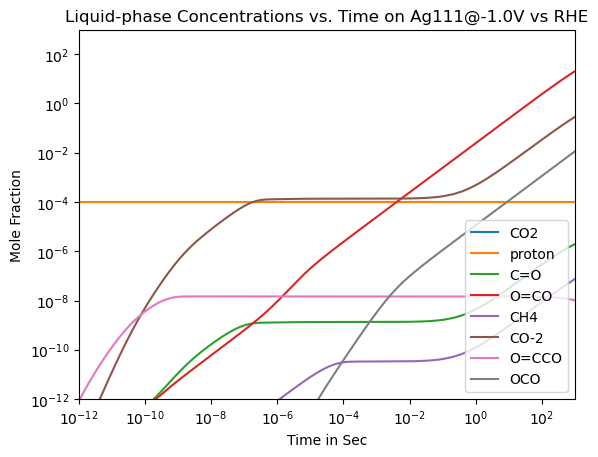

In [37]:
exclude_species = ["H2O"]
plotC(ssys.sims[1], 1e-8, 1e3, exclude_species)
xscale("log")
yscale("log")
xlim(1e-12, 1e3)
ylim(1e-12, 1e3)
title("Liquid-phase Concentrations vs. Time on Ag111@-1.0V vs RHE")
gcf()

In [ ]:
# Plot liquid-phase concentrations
function plotCL(bsol, tol, t_end, exclude)
    # Species order and corresponding colors for the main species
    species_order = ["CO2", "proton", "H2", "CH4", "O=CO", "C=O", "CO-2", "OCCO"]
    color_map = Dict("CO2" => "magenta", "proton" => "black", "H2" => "blue",
                        "CH4" => "red", "O=CO" => "green", "C=O" => "purple",
                        "CO-2" => "brown", "OCCO" => "grey")
    # Replacement map for species labels
    replacement_map = Dict("O=CO" => "HCOOH", "C=O" => "HCHO", "CO-2" => "CH3OH",
                            "OCCO" => "HOCH2CH2OH")

    clf()
    xs = concentrations(bsol)
    maxes = maximum(xs, dims=2)
    spnames = []
    plotted_species = Set{String}()

    # Filter data to the specified time range
    if t_end !== nothing
        t_mask = bsol.sol.t .<= t_end
        ts = bsol.sol.t[t_mask]
        xs = xs[:, t_mask]
    else
        ts = bsol.sol.t
    end

    # Plot species in the specified order with custom colors and labels
    for sp in species_order
        # Find the species index in the phase
        species_index = findfirst(x -> x.name == sp, bsol.domain.phase.species)
        if species_index === nothing || maxes[species_index] <= tol || sp in exclude
            continue
        end

        # Apply replacement for display name if available
        display_name = get(replacement_map, sp, sp)

        # Plot the species with the specified color
        plot(ts, xs[species_index, :], label=display_name, color=color_map[sp])
        push!(spnames, display_name)
        push!(plotted_species, sp)
    end

    # Plot any remaining species that are above the tolerance and not already plotted
    for i = 1:length(bsol.domain.phase.species)
        sp = bsol.domain.phase.species[i].name
        if maxes[i] > tol && !(sp in exclude) && !(sp in plotted_species)
            plot(ts, xs[i, :], label=sp)
            push!(spnames, sp)
        end
    end

    # Configure the legend and labels
    xlabel("Time (s)", fontsize=16)
    ylabel("Concentration (mol/m^3)", fontsize=16)
    xticks(fontsize=14)
    yticks(fontsize=14)
    legend(spnames, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=12, ncol=1)
end

plotCL (generic function with 1 method)

In [20]:
Dict([ssys.sims[2].names[i]=>molefractions(ssys.sims[2],1.0)[i] for i in 1:length(ssys.sims[2].names)])

Dict{String, Float64} with 135 entries:
  "O=C=C[Pt]"     => 1.29812e-45
  "O=CC=[Pt]"     => 1.13445e-43
  "COC=O.[Pt]"    => 2.63046e-12
  "OC(O)C#[Pt]"   => 7.13587e-54
  "OCOC[Pt]"      => 1.34665e-37
  "OCO[Pt]"       => 5.79863e-24
  "OCC(O)[Pt]"    => 2.93243e-22
  "O=C=C=O.[Pt]"  => 1.17376e-80
  "CO[Pt]"        => 2.23725e-19
  "CH2X"          => 5.18065e-24
  "C=C=O.[Pt]"    => 1.66458e-32
  "O=C(CO)C[Pt]"  => 8.91665e-38
  "COC(=O)C#[Pt]" => 5.30398e-60
  "CH2OX"         => 9.1987e-9
  "O=COC=[Pt]"    => 3.3892e-61
  "OC=CO[Pt]"     => 5.88854e-41
  "O=CC[Pt]"      => 2.01818e-38
  "COO.[Pt]"      => 4.01359e-55
  "CC(O)O.[Pt]"   => 1.69232e-27
  ⋮               => ⋮

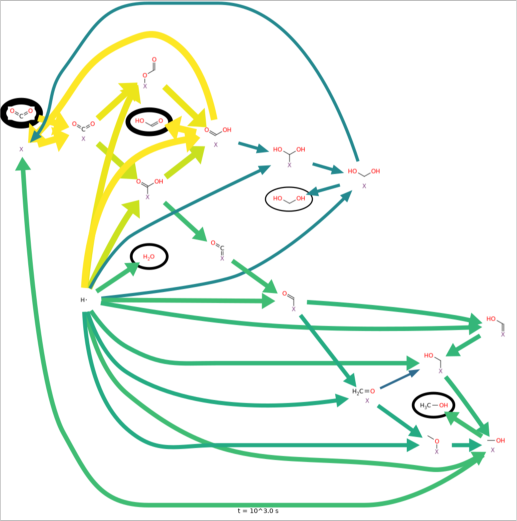

In [40]:
getfluxdiagram(ssys,1e3;speciesratetolerance=1e-6)

In [22]:
println(ssys.names)

["Ar", "He", "Ne", "N2", "CO2", "proton", "H", "C=O", "O=CO", "H2O", "O=CC=O", "CO", "O2", "O=C=C=O", "H2", "CH4", "OO", "COC=O", "COO", "CO-2", "COOC", "O=CCO", "OCO", "COCO", "OCCO", "O=C=CO", "OC=CO", "C=C=O", "C=CO", "C=C", "CC=O", "O=O", "C=C(O)O", "CC(=O)O", "COC", "CCO", "CC(O)O", "CC(=O)C=O", "CCOC=O", "COCC=O", "CCOO", "CC", "COC(C)=O", "CC(=O)CO", "CC(C)=O", "CC(=O)C(C)=O", "COCOC", "CCOOC", "O=C=CC=O", "O=CC=CO", "C=CC=O", "O=CC=CC=O", "CC(O)C=O", "COCCO", "CCOCO", "C=C(O)C=O", "COC(C)O", "CC(O)CO", "CC(C)O", "CC(=O)C(C)O", "CC(O)C(C)O", "CC(O)=C=O", "CC(O)=CO", "C=C(C)O", "CC(O)=CC=O", "CC(O)=C(C)O", "C=C(O)OC", "C=C(O)CO", "C=COC=O", "O=C=C=C=O", "O=C=C=CO", "C=C=C=O", "O=C=C=CC=O", "CC(O)=C=C=O", "O=C=C=C=C=O", "COC=C=O", "O=CCC=O", "O=CCCO", "CCC=O", "CC(=O)CC=O", "CC(O)CC=O", "O=CCCC=O", "CCC(=O)O", "CCOC", "CCCO", "CCC(O)O", "CCC(=O)C=O", "CCCOC=O", "CCOCC=O", "CCCOO", "CCC", "CCC(C)=O", "CCC(=O)OC", "CCOCOC", "CCCOOC", "CCC(O)C=O", "CCC(=O)CO", "CCOCCO", "CCCOCO", "CC

In [23]:
plotrops(ssys,"CH2O2X",1;N=15,tol=0.0)

In [24]:
plotrops(ssys,"CHO2X",1;N=10,tol=0.0)

In [25]:
plotrops(ssys,"CO2HX",1;N=10,tol=0.0)

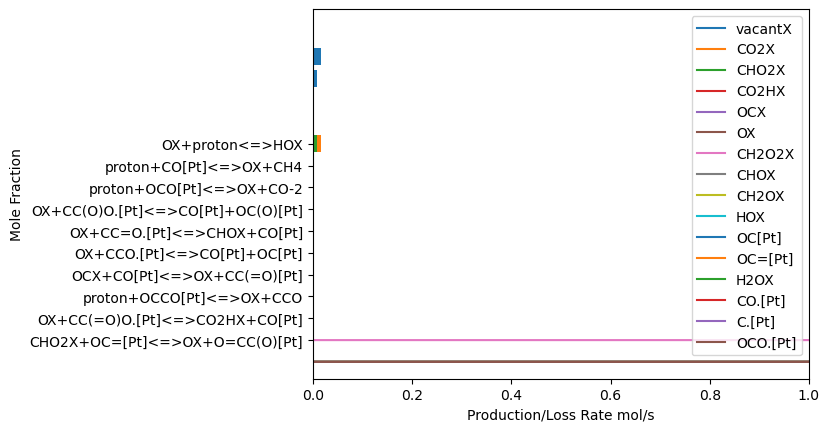

In [26]:
plotrops(ssys,"OX",1;N=10,tol=0.0)
gcf()

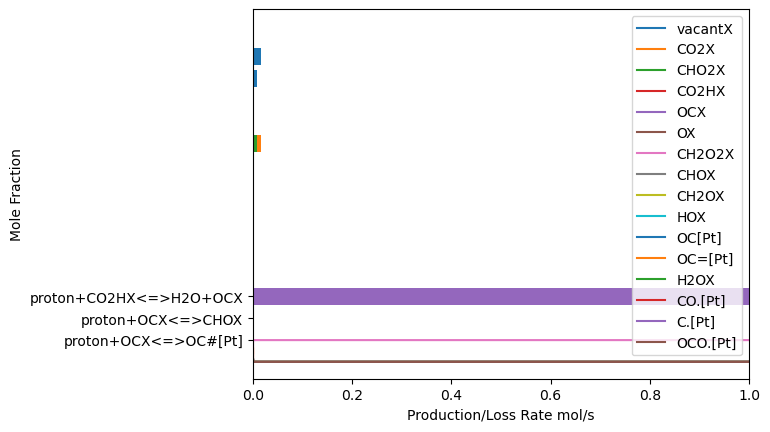

In [27]:
plotrops(ssys,"OCX",1.0e-6)
gcf()

In [28]:
for (i,rxn) in enumerate(inter.reactions)
    str = getrxnstr(rxn)
    kf = inter.kfs[i]
    krev = inter.krevs[i]
    Kc = kf/krev
    println(str)
    println("kf = $kf")
    println("krev = $krev")
    println("Kc = $Kc")
end

vacantX+CO2<=>CO2X
kf = 20654.615923781494
krev = 11189.298481041604
Kc = 1.8459259048971917
proton+CO2X<=>CHO2X
kf = 2.9017416446582456e9
krev = 1899.66702548246
Kc = 1.527500138568383e6
proton+CO2X<=>CO2HX
kf = 1.463583681202455e9
krev = 3.811669269832601e-9
Kc = 3.839744682955487e17
proton+CHO2X<=>CH2O2X
kf = 6.631433080632379e21
krev = 2.4248572957443027e-21
Kc = 2.7347725131168515e42
proton+CO2HX<=>CH2O2X
kf = 6.057681090955825e13
krev = 5.568090548283688e-18
Kc = 1.0879279060616297e31
proton+OCX<=>CHOX
kf = 1.957021683651188e16
krev = 2.0461352079269518e-11
Kc = 9.564478808973482e26
proton+CHOX<=>CH2OX
kf = 5.647211727381022e12
krev = 1.5706516446005796e-14
Kc = 3.595457813191366e26
vacantX+vacantX+CO2<=>OX+OCX
kf = 3.0109478093923404e-24
krev = 3.037156297092479e15
Kc = 9.913707148607306e-40
OX+proton<=>HOX
kf = 1.9772207091832303e21
krev = 3.7740008840727066e-10
Kc = 5.239057355623923e30
vacantX+C=O<=>CH2OX
kf = 500114.13488002896
krev = 399.6803280141717
Kc = 1251.285339373260

In [29]:
for (i,rxn) in enumerate(inter.reactions)
    str = getrxnstr(rxn)
    kf = inter.kfs[i]
    krev = inter.krevs[i]
    Kc = kf/krev
    println(str)
    println("kf = $kf")
    println("krev = $krev")
    println("Kc = $Kc")
end

vacantX+CO2<=>CO2X
kf = 20654.615923781494
krev = 11189.298481041604
Kc = 1.8459259048971917
proton+CO2X<=>CHO2X
kf = 2.9017416446582456e9
krev = 1899.66702548246
Kc = 1.527500138568383e6
proton+CO2X<=>CO2HX
kf = 1.463583681202455e9
krev = 3.811669269832601e-9
Kc = 3.839744682955487e17
proton+CHO2X<=>CH2O2X
kf = 6.631433080632379e21
krev = 2.4248572957443027e-21
Kc = 2.7347725131168515e42
proton+CO2HX<=>CH2O2X
kf = 6.057681090955825e13
krev = 5.568090548283688e-18
Kc = 1.0879279060616297e31
proton+OCX<=>CHOX
kf = 1.957021683651188e16
krev = 2.0461352079269518e-11
Kc = 9.564478808973482e26
proton+CHOX<=>CH2OX
kf = 5.647211727381022e12
krev = 1.5706516446005796e-14
Kc = 3.595457813191366e26
vacantX+vacantX+CO2<=>OX+OCX
kf = 3.0109478093923404e-24
krev = 3.037156297092479e15
Kc = 9.913707148607306e-40
OX+proton<=>HOX
kf = 1.9772207091832303e21
krev = 3.7740008840727066e-10
Kc = 5.239057355623923e30
vacantX+C=O<=>CH2OX
kf = 500114.13488002896
krev = 399.6803280141717
Kc = 1251.285339373260